# Exploratory data analysis

### Data description in satisfaction_survey.csv

Factor Descriptions:
- Gender — passenger's gender (binary: Female, Male).
- Customer Type — passenger type (categorical: Loyal customer, disloyal Customer).
- Age — passenger's age (numerical).
- Type of Travel — purpose of the flight (binary: Personal Travel, Business Travel).
- Class — flight class (categorical: Business, Eco, Eco Plus).
- Flight distance — flight distance in miles (numerical).
- Inflight wifi service — satisfaction level with the inflight Wi-Fi service (numerical: 1–5 or 0 if not rated).
- Departure/Arrival time convenient — satisfaction level with the departure/arrival time (numerical: 1–5 or 0 if not rated).
- Ease of Online booking — satisfaction level with the online booking process (numerical: 1–5 or 0 if not rated).
- Gate location — satisfaction level with the gate location (numerical: 1–5 or 0 if not rated).
- Food and drink — satisfaction level with the food and drink service (numerical: 1–5 or 0 if not rated).
- Online boarding — satisfaction level with the online boarding process (numerical: 1–5 or 0 if not rated).
- Seat comfort — satisfaction level with the seat comfort (numerical: 1–5 or 0 if not rated).
- Inflight entertainment — satisfaction level with the inflight entertainment (numerical: 1–5 or 0 if not rated).
- On-board service — satisfaction level with the on-board service (numerical: 1–5 or 0 if not rated).
- Leg room service — satisfaction level with the leg room service (numerical: 1–5 or 0 if not rated).
- Baggage handling — satisfaction level with the baggage handling (numerical: 1–5 or 0 if not rated).
- Checkin service — satisfaction level with the check-in service (numerical: 1–5 or 0 if not rated).
- Cleanliness — satisfaction level with the cleanliness of the aircraft (numerical: 1–5 or 0 if not rated).
- Departure Delay in Minutes — total departure delay in minutes (numerical).
- Arrival Delay in Minutes — total arrival delay in minutes (numerical).

Target variable:
- satisfaction — overall flight satisfaction (binary: False — passenger was dissatisfied, True — passenger was satisfied).

### Loading and initial exploration of flight satisfaction data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from category_encoders import BinaryEncoder
from IPython.display import HTML, display

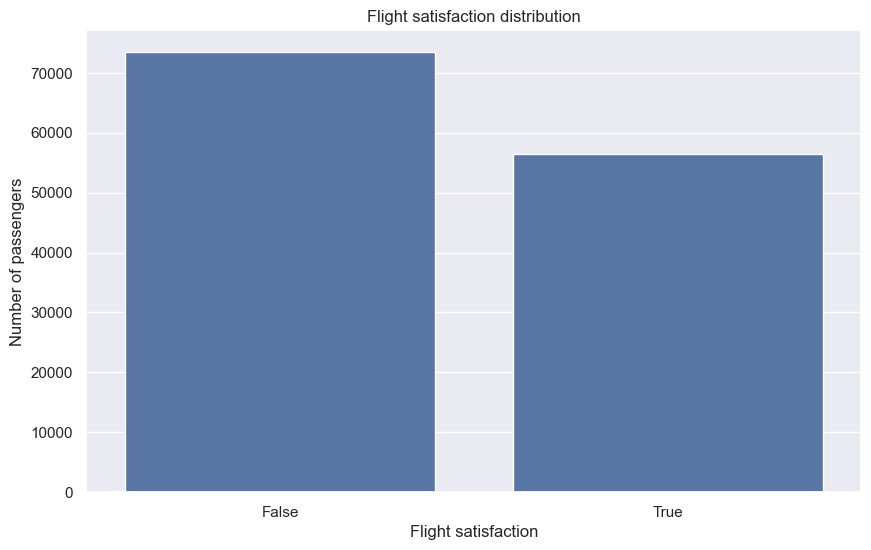

In [2]:
# Loading data
flight_data = pd.read_csv('../../data/satisfaction_survey.csv')
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Separating features from target variable
feature = flight_data.drop(columns='satisfaction')
target = flight_data['satisfaction']

# Visualization of target variable distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=target)
plt.title('Flight satisfaction distribution')
plt.xlabel('Flight satisfaction')
plt.ylabel('Number of passengers')
plt.show()

The chart shows that the data is balanced across the target class, ensuring proper conditions for model training.

### Creating training and test sets

In [3]:
# Splitting data into training and test sets (75%:25%)
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.25, random_state=52, stratify=target)

# Combining data for analysis
train_data = x_train.copy(deep=True)
train_data['satisfaction'] = y_train

print(f'Training set size: {len(x_train)}')
print(f'Test set size: {len(x_test)}')

Training set size: 97410
Test set size: 32470


### Handling missing values

In [4]:
print('Checking for missing values in data:')
display(train_data.isna().sum().to_frame(''))

Checking for missing values in data:


,
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


The "Arrival Delay in Minutes" feature has a small number of missing values. They will be replaced with the median value.

In [5]:
arrival_delay_median = train_data['Arrival Delay in Minutes'].median()
train_data['Arrival Delay in Minutes'] = train_data[
    'Arrival Delay in Minutes'].fillna(arrival_delay_median)
x_test['Arrival Delay in Minutes'] = x_test[
    'Arrival Delay in Minutes'].fillna(arrival_delay_median)

omissions = train_data.isna().sum().sum()
print(f'Total number of missing values after filling: {omissions}')

Total number of missing values after filling: 0


### Identifying feature types

Feature types were manually defined based on the data description.

In [6]:
# Numerical features
numeric_features = ['Age', 'Flight Distance', 'Departure Delay in Minutes',
                    'Arrival Delay in Minutes']

# Binary categorical features
binary_features = ['Gender', 'Customer Type', 'Type of Travel']

# Multiclass categorical features
multiclass_features = ['Class']

# Rating features (0-5, treated as categorical)
rating_features = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Cleanliness']

# All categorical features
categorical_features = binary_features + multiclass_features + rating_features

### Analyzing relationships between numerical features and satisfaction

In [7]:
# Analyzing correlation relationships
numeric_data = train_data[numeric_features + ['satisfaction']].copy(deep=True)
correlation_matrix = numeric_data.corr()['satisfaction']

print('Correlation of numerical features with satisfaction:')
display(correlation_matrix.sort_values(ascending=False).to_frame(''))

# Analyzing significant correlations
significant_correlations = correlation_matrix[
    (correlation_matrix >= 0.051) | (correlation_matrix <= -0.051)]
print('\nStatistically significant correlations:')
display(significant_correlations.sort_values(ascending=False).to_frame(''))

Correlation of numerical features with satisfaction:


,
satisfaction,1.000000
Flight Distance,0.298659
Age,0.134240
Departure Delay in Minutes,-0.050080
Arrival Delay in Minutes,-0.056980



Statistically significant correlations:


,
satisfaction,1.000000
Flight Distance,0.298659
Age,0.134240
Arrival Delay in Minutes,-0.056980


There is a strong correlation between "Flight Distance" and the target variable, indicating its high predictive importance for the model.

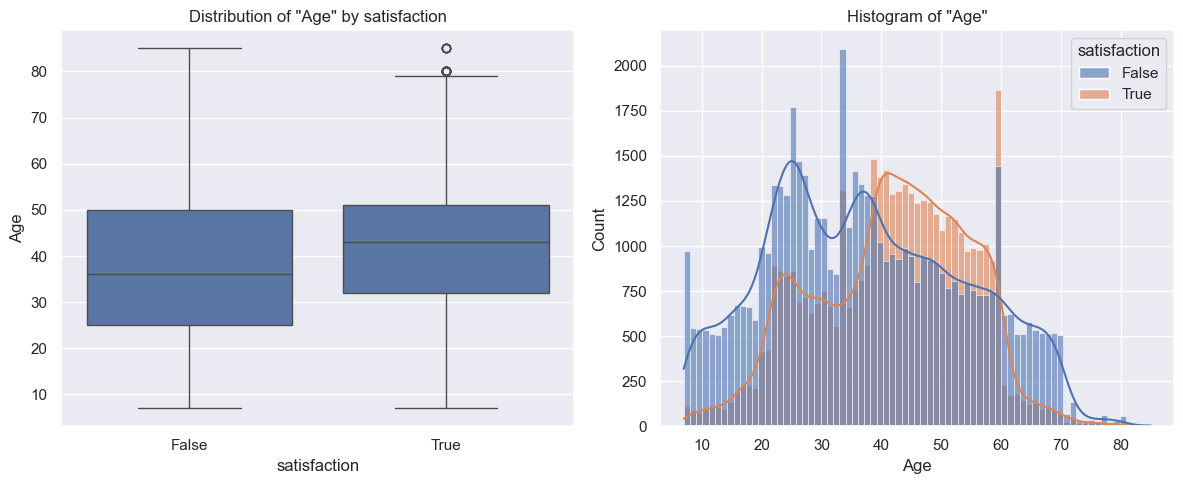

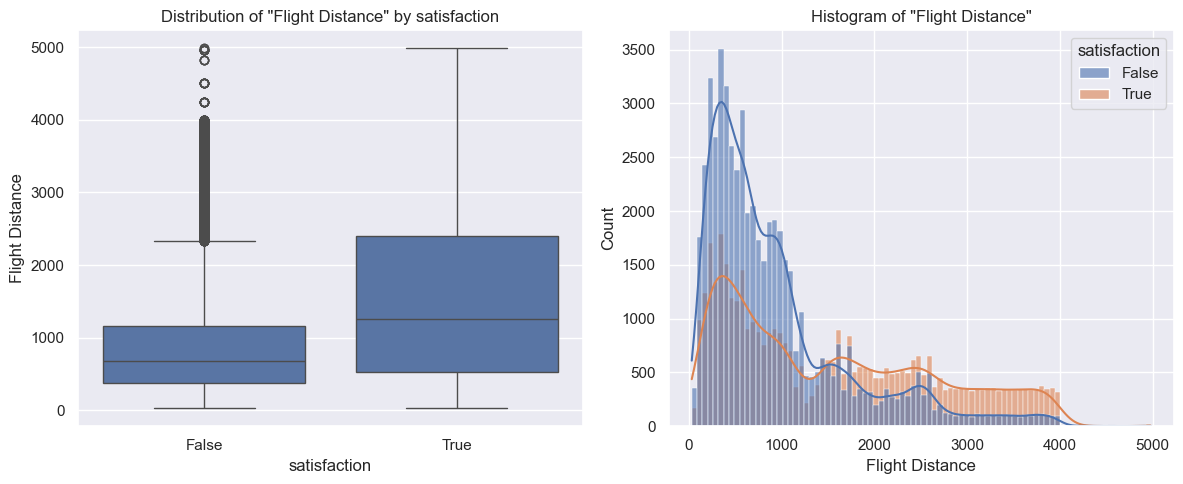

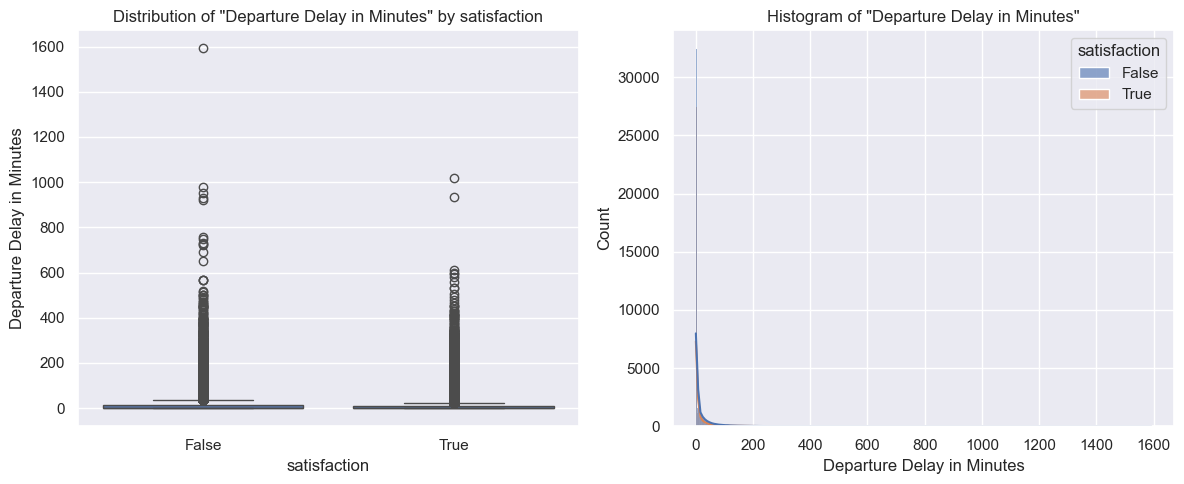

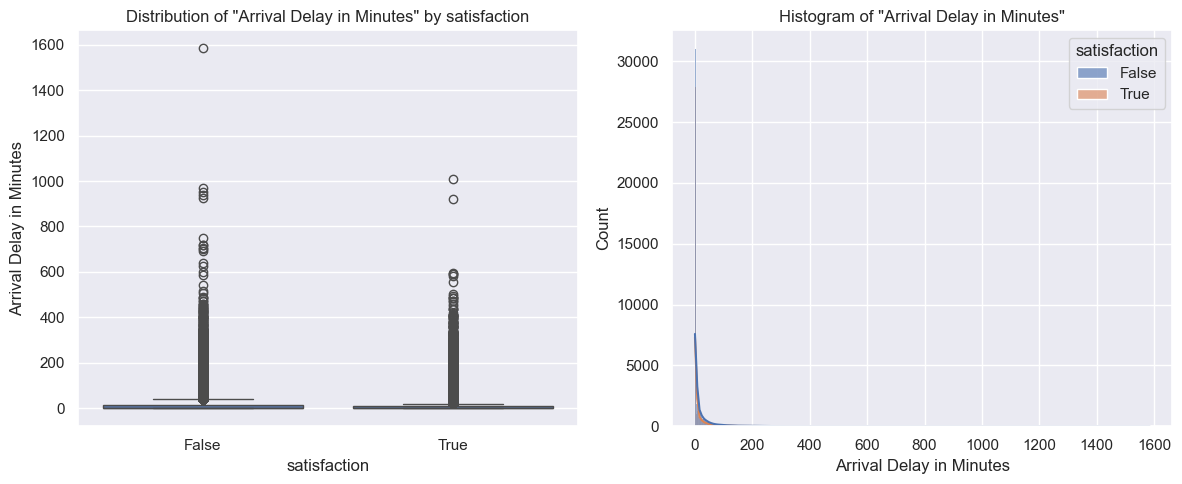

In [8]:
# Visualizing distributions of numerical features
for feature in numeric_features:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(x='satisfaction', y=feature, data=train_data)
    plt.title(f'Distribution of "{feature}" by satisfaction')

    plt.subplot(1, 2, 2)
    sns.histplot(data=train_data, x=feature, hue='satisfaction',
                 kde=True, alpha=0.6)
    plt.title(f'Histogram of "{feature}"')

    plt.tight_layout()
    plt.show()

The charts show that middle-aged and older passengers tend to be more satisfied with flights than younger passengers. Satisfaction also increases with flight distance, and the absence of departure and arrival delays is directly associated with positive ratings.

### Analyzing relationships between categorical features and satisfaction

In [9]:
def analyze_categorical_influence(data, categorical_cols,
                                  target_col='satisfaction'):
    """Analyzes the influence of categorical features on the target variable"""
    influence_metrics = []

    for feature in categorical_cols:
        # Aggregating mean values of target variable by categories
        aggregated_data = data.groupby(feature, as_index=False).agg({
            target_col: ['mean', 'count']})
        aggregated_data.columns = [feature, 'satisfaction_mean', 'count']

        # Calculating influence metrics
        target_values = aggregated_data['satisfaction_mean'].values
        influence_metrics.append({
            'factor': feature,
            'range': np.max(target_values) - np.min(target_values),
            'min_satisfaction': np.min(target_values),
            'max_satisfaction': np.max(target_values),
            'categories count': len(aggregated_data)
        })

    return pd.DataFrame(influence_metrics)

In [10]:
# Analyzing influence of categorical features
categorical_analysis = analyze_categorical_influence(
    train_data, categorical_features)
categorical_analysis = categorical_analysis.sort_values(
    'range', ascending=False)

print('Analysis of categorical features influence on satisfaction:')
display(HTML(categorical_analysis.to_html(index=False)))

Analysis of categorical features influence on satisfaction:


factor,range,min_satisfaction,max_satisfaction,categories count
Online boarding,0.755665,0.115810,0.871474,6
Inflight wifi service,0.750194,0.247393,0.997587,6
Gate location,0.653300,0.346700,1.000000,6
Seat comfort,0.651910,0.000000,0.651910,6
Inflight entertainment,0.651608,0.000000,0.651608,6
On-board service,0.646891,0.000000,0.646891,6
Cleanliness,0.614654,0.000000,0.614654,6
Checkin service,0.612221,0.000000,0.612221,6
Class,0.507482,0.187301,0.694783,3
Type of Travel,0.481757,0.101585,0.583342,2


Feature importance analysis based on the range metric revealed that service factors - "Online boarding" and "Inflight wifi service" - have the greatest influence on the target variable. Meanwhile, "Gender" and "Departure/Arrival time convenient" factors show minimal predictive power and likely contribute little to the model's predictions.

In [11]:
# Automatic selection of most significant categorical features
significant_categorical_features = categorical_analysis[
    categorical_analysis['range'] > 0.2
]['factor'].tolist()

print('Significant categorical features:')
display(significant_categorical_features)

Significant categorical features:


['Online boarding',
 'Inflight wifi service',
 'Gate location',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Cleanliness',
 'Checkin service',
 'Class',
 'Type of Travel',
 'Ease of Online booking',
 'Leg room service',
 'Baggage handling',
 'Food and drink',
 'Customer Type']

In [12]:
# Detailed analysis of significant features
for feature in significant_categorical_features:
    print(f'\nDetailed analysis for feature "{feature}":')
    analysis_table = train_data.groupby(
        [feature, 'satisfaction'], as_index=False).agg(
            {'Age': 'count'}).pivot(
                index=feature, columns='satisfaction', values='Age')
    analysis_table['satisfaction_rate'] = (
        analysis_table[True] / (analysis_table[True] + analysis_table[False]))
    display(analysis_table)


Detailed analysis for feature "Online boarding":


satisfaction,False,True,satisfaction_rate
Online boarding,,,
0,1019,1284,0.557534
1,8632,1335,0.133942
2,14552,1906,0.115810
3,17470,2823,0.139112
4,10896,17886,0.621430
5,2520,17087,0.871474



Detailed analysis for feature "Inflight wifi service":


satisfaction,False,True,satisfaction_rate
Inflight wifi service,,,
0,7,2894,0.997587
1,11329,5548,0.328731
2,18259,6002,0.247393
3,17913,6083,0.253501
4,7467,11132,0.598527
5,114,10662,0.989421



Detailed analysis for feature "Gate location":


...

satisfaction,False,True,satisfaction_rate
Baggage handling,,,
1,4756,2070,0.303252
2,7625,3165,0.293327
3,14762,4562,0.236079
4,18257,16901,0.480716
5,9689,15623,0.617217



Detailed analysis for feature "Food and drink":


satisfaction,False,True,satisfaction_rate
Food and drink,,,
0,54,46,0.460000
1,9692,2359,0.195751
2,12617,7948,0.386482
3,12500,8325,0.399760
4,10874,12075,0.526167
5,9352,11568,0.552964



Detailed analysis for feature "Customer Type":


satisfaction,False,True,satisfaction_rate
Customer Type,,,
Loyal Customer,41500,38089,0.478571
disloyal Customer,13589,4232,0.237473


Table analysis shows a clear dependency: for the most influential factors like "Online boarding" and "Inflight wifi service", satisfaction levels change dramatically depending on the service rating. For example, with the highest rating of 5 for online boarding, the proportion of satisfied passengers is 87%, while with a rating of 2 it's only 11.6%. Similarly, for Wi-Fi, maximum satisfaction (99.7%) is observed with ratings of 0 and 5. Categorical factors like "Class" and "Type of Travel" also show strong relationships: business class passengers and passengers traveling for business purposes are significantly more satisfied. This confirms that these categorical variables are highly informative for the model.

### Analyzing relationships between categorical features

In [13]:
# Analyzing relationships between services
print('Analyzing probable relationships between categorical features:')
service_features = ['Inflight wifi service', 'Food and drink',
                    'Seat comfort', 'Inflight entertainment']
for i in range(len(service_features)):
    for j in range(i+1, len(service_features)):
        col_x = service_features[i]
        col_y = service_features[j]

        print(f'\nRelationship between "{col_x}" and "{col_y}":')
        cross_table = train_data.groupby([col_x, col_y], as_index=False).agg({
            'satisfaction': 'count'}).pivot(
                index=col_x, columns=col_y, values='satisfaction')
        display(cross_table.fillna(0).astype(int))

Analyzing probable relationships between categorical features:

Relationship between "Inflight wifi service" and "Food and drink":


Food and drink,0,1,2,3,4,5
Inflight wifi service,,,,,,
0,49,313,617,673,624,625
1,24,3480,3144,3146,3591,3492
2,14,2950,7311,4517,4836,4633
3,7,2751,4376,7338,4857,4667
4,2,1796,3288,3264,6641,3608
5,4,761,1829,1887,2400,3895



Relationship between "Inflight wifi service" and "Seat comfort":


Seat comfort,0,1,2,3,4,5
Inflight wifi service,,,,,,
0,0,342,370,448,856,885
1,0,3014,1979,2663,4967,4254
2,0,2768,5377,4247,6574,5295
3,0,2682,3133,6328,6539,5314
4,1,1725,2089,2780,7490,4514
5,0,840,945,1027,3379,4585



Relationship between "Inflight wifi service" and "Inflight entertainment":


...

Seat comfort,0,1,2,3,4,5
Food and drink,,,,,,
0,0,22,21,24,19,14
1,1,7986,847,1455,1221,541
2,0,916,9941,1847,4296,3565
3,0,892,1183,10756,4424,3570
4,0,841,1025,1794,15522,3767
5,0,714,876,1617,4323,13390



Relationship between "Food and drink" and "Inflight entertainment":


Inflight entertainment,0,1,2,3,4,5
Food and drink,,,,,,
0,10,13,11,21,29,16
1,1,8791,726,846,973,714
2,1,780,12001,1491,3520,2772
3,0,833,1322,12458,3374,2838
4,1,722,1258,1532,16462,2974
5,0,652,1196,1440,3283,14349



Relationship between "Seat comfort" and "Inflight entertainment":


Inflight entertainment,0,1,2,3,4,5
Seat comfort,,,,,,
0,0,0,0,0,1,0
1,0,7655,723,831,1138,1024
2,4,680,9635,1161,1361,1052
3,4,1203,2083,10812,2050,1341
4,5,1487,2657,2962,17095,5599
5,0,766,1416,2022,5996,14647


Table analysis reveals stable relationships between key service factors. There is a clear positive correlation: passengers who highly rate one service (e.g., Wi-Fi or food) tend to similarly rate other related services (seat comfort, entertainment). This indicates the formation of an overall flight impression where the rating isn't reduced to one isolated factor. Additionally, rating distributions across categories for related factors are very similar, suggesting their potential collinearity.

In [14]:
# Analyzing relationship between travel type and class
print('Relationship between "Type of Travel" and "Class":')
travel_class_table = train_data.groupby(
    ['Type of Travel', 'Class'], as_index=False).agg(
        {'satisfaction': ['count', 'mean']})
display(travel_class_table)

Relationship between "Type of Travel" and "Class":


Type of Travel     Class satisfaction          
                                    count      mean
0  Business travel  Business        44669  0.720679
1  Business travel       Eco        18977  0.298150
2  Business travel  Eco Plus         3661  0.385960
3  Personal Travel  Business         2006  0.118146
4  Personal Travel       Eco        24712  0.102177
5  Personal Travel  Eco Plus         3385  0.087445

Travel type and service class have a strong relationship with satisfaction levels. Business travelers, especially those flying business class, show significantly higher satisfaction (72%), while personal travelers flying economy class have extremely low ratings (around 10%).

### Selecting final feature set

In [15]:
# Excluding insignificant or highly correlated features
excluded_features = ['Arrival Delay in Minutes', 'Gate location',
                     'Baggage handling']

# Final feature set
final_numeric_features = [f for f in numeric_features
                          if f not in excluded_features]
final_categorical_features = [f for f in significant_categorical_features
                              if f not in excluded_features]

# Separating final categorical features by type
final_binary_features = [f for f in final_categorical_features
                         if f in binary_features]
final_multiclass_features = [f for f in final_categorical_features
                             if f in multiclass_features]
final_rating_features = [f for f in final_categorical_features
                         if f in rating_features]

print('Final numerical features:')
print(final_numeric_features)

print('\nFinal binary features:')
print(final_binary_features)

print('\nFinal multiclass features:')
print(final_multiclass_features)

print('\nFinal rating features:')
display(final_rating_features)

Final numerical features:
['Age', 'Flight Distance', 'Departure Delay in Minutes']

Final binary features:
['Type of Travel', 'Customer Type']

Final multiclass features:
['Class']

Final rating features:


['Online boarding',
 'Inflight wifi service',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Cleanliness',
 'Checkin service',
 'Ease of Online booking',
 'Leg room service',
 'Food and drink']

### Preparing data for modeling

In [16]:
# Preparing training set
x_train_processed = x_train[
    final_numeric_features + final_categorical_features].copy(deep=True)
x_test_processed = x_test[
    final_numeric_features + final_categorical_features].copy(deep=True)

# Binary encoding for all categorical features
binary_encoders = {}

# Encoding binary features
for feature in final_binary_features:
    encoder = BinaryEncoder()
    encoded_train = encoder.fit_transform(x_train_processed[feature])
    encoded_test = encoder.transform(x_test_processed[feature])

    # Adding encoded columns
    for col in encoded_train.columns:
        x_train_processed[col] = encoded_train[col]
        x_test_processed[col] = encoded_test[col]

    # Removing original column
    x_train_processed.drop(columns=[feature], inplace=True)
    x_test_processed.drop(columns=[feature], inplace=True)

    binary_encoders[feature] = encoder

# Encoding multiclass features
for feature in final_multiclass_features:
    encoder = BinaryEncoder()
    encoded_train = encoder.fit_transform(x_train_processed[feature])
    encoded_test = encoder.transform(x_test_processed[feature])

    # Adding encoded columns
    for col in encoded_train.columns:
        x_train_processed[col] = encoded_train[col]
        x_test_processed[col] = encoded_test[col]

    # Removing original column
    x_train_processed.drop(columns=[feature], inplace=True)
    x_test_processed.drop(columns=[feature], inplace=True)

    binary_encoders[feature] = encoder

# Encoding rating features (0-5) as categorical
for feature in final_rating_features:
    # Converting to string type for proper binary encoding
    x_train_processed[feature] = x_train_processed[feature].astype(str)
    x_test_processed[feature] = x_test_processed[feature].astype(str)

    encoder = BinaryEncoder()
    encoded_train = encoder.fit_transform(x_train_processed[feature])
    encoded_test = encoder.transform(x_test_processed[feature])

    # Adding encoded columns
    for col in encoded_train.columns:
        x_train_processed[col] = encoded_train[col]
        x_test_processed[col] = encoded_test[col]

    # Removing original column
    x_train_processed.drop(columns=[feature], inplace=True)
    x_test_processed.drop(columns=[feature], inplace=True)

    binary_encoders[feature] = encoder

# Identifying columns for scaling (only numerical features)
numeric_cols = final_numeric_features
categorical_cols = [col for col in x_train_processed.columns
                   if col not in numeric_cols]

# Scaling only numerical features
scaler = StandardScaler()
x_train_numeric_scaled = scaler.fit_transform(x_train_processed[numeric_cols])
x_test_numeric_scaled = scaler.transform(x_test_processed[numeric_cols])

# Creating final DataFrame with scaled numerical and original categorical
# features
x_train_final = pd.DataFrame(
    x_train_numeric_scaled,
    columns=numeric_cols,
    index=x_train_processed.index
)

x_test_final = pd.DataFrame(
    x_test_numeric_scaled,
    columns=numeric_cols,
    index=x_test_processed.index
)

# Adding categorical features without changes
for col in categorical_cols:
    x_train_final[col] = x_train_processed[col].values
    x_test_final[col] = x_test_processed[col].values

### Displaying prepared data

In [17]:
print('Encoded training data (first 5 rows):')
display(x_train_processed.head())

print('\nScaled training data (first 5 rows):')
display(x_train_final.head())

Encoded training data (first 5 rows):


,Age,Flight Distance,Departure Delay in Minutes,Type of Travel_0,Type of Travel_1,Customer Type_0,Customer Type_1,Class_0,Class_1,Online boarding_0,...,Checkin service_2,Ease of Online booking_0,Ease of Online booking_1,Ease of Online booking_2,Leg room service_0,Leg room service_1,Leg room service_2,Food and drink_0,Food and drink_1,Food and drink_2
127781,53,1440,0,0,1,0,1,0,1,0,...,1,0,0,1,0,0,1,0,0,1
124940,8,476,1,1,0,0,1,1,0,0,...,0,0,0,1,0,1,0,0,1,0
82668,26,484,9,0,1,0,1,1,0,0,...,0,0,1,0,0,1,0,0,1,1
13890,35,2381,11,0,1,0,1,1,1,0,...,1,0,1,1,0,1,1,0,1,0
58120,27,409,0,1,0,0,1,1,1,0,...,1,0,0,1,1,0,0,0,1,1



Scaled training data (first 5 rows):


,Age,Flight Distance,Departure Delay in Minutes,Type of Travel_0,Type of Travel_1,Customer Type_0,Customer Type_1,Class_0,Class_1,Online boarding_0,...,Checkin service_2,Ease of Online booking_0,Ease of Online booking_1,Ease of Online booking_2,Leg room service_0,Leg room service_1,Leg room service_2,Food and drink_0,Food and drink_1,Food and drink_2
127781,0.898634,0.248660,-0.389023,0,1,0,1,0,1,0,...,1,0,0,1,0,0,1,0,0,1
124940,-2.081556,-0.717913,-0.362395,1,0,0,1,1,0,0,...,0,0,0,1,0,1,0,0,1,0
82668,-0.889480,-0.709892,-0.149370,0,1,0,1,1,0,0,...,0,0,1,0,0,1,0,0,1,1
13890,-0.293442,1.192171,-0.096114,0,1,0,1,1,1,0,...,1,0,1,1,0,1,1,0,1,0
58120,-0.823254,-0.785092,-0.389023,1,0,0,1,1,1,0,...,1,0,0,1,1,0,0,0,1,1


In [18]:
print('Encoded test data (first 5 rows):')
display(x_test_processed.head())

print('\nScaled test data (first 5 rows):')
display(x_test_final.head())

Encoded test data (first 5 rows):


,Age,Flight Distance,Departure Delay in Minutes,Type of Travel_0,Type of Travel_1,Customer Type_0,Customer Type_1,Class_0,Class_1,Online boarding_0,...,Checkin service_2,Ease of Online booking_0,Ease of Online booking_1,Ease of Online booking_2,Leg room service_0,Leg room service_1,Leg room service_2,Food and drink_0,Food and drink_1,Food and drink_2
95435,14,489,76,1,0,0,1,1,0,0,...,1,1,0,0,0,0,1,0,0,1
69214,57,757,2,0,1,0,1,0,1,0,...,1,0,1,0,0,1,0,0,1,1
111885,24,1024,22,0,1,1,0,1,0,1,...,0,0,1,0,0,1,0,1,0,1
84992,56,407,0,0,1,0,1,0,1,0,...,1,1,0,0,0,1,0,0,1,0
20174,11,930,21,0,1,1,0,1,0,1,...,1,0,1,1,0,1,0,0,1,1



Scaled test data (first 5 rows):


,Age,Flight Distance,Departure Delay in Minutes,Type of Travel_0,Type of Travel_1,Customer Type_0,Customer Type_1,Class_0,Class_1,Online boarding_0,...,Checkin service_2,Ease of Online booking_0,Ease of Online booking_1,Ease of Online booking_2,Leg room service_0,Leg room service_1,Leg room service_2,Food and drink_0,Food and drink_1,Food and drink_2
95435,-1.684197,-0.704879,1.634711,1,0,0,1,1,0,0,...,1,1,0,0,0,0,1,0,0,1
69214,1.163540,-0.436163,-0.335767,0,1,0,1,0,1,0,...,1,0,1,0,0,1,0,0,1,1
111885,-1.021933,-0.168451,0.196795,0,1,1,0,1,0,1,...,0,0,1,0,0,1,0,1,0,1
84992,1.097313,-0.787097,-0.389023,0,1,0,1,0,1,0,...,1,1,0,0,0,1,0,0,1,0
20174,-1.882877,-0.262702,0.170167,0,1,1,0,1,0,1,...,1,0,1,1,0,1,0,0,1,1


# Model creation and training

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

### Data preparation

In [20]:
# Reading data
x_train = x_train_final
y_train = y_train
x_test = x_test_final
y_test = y_test

# Splitting training data into training and validation sets (75%:25%)
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train, test_size=0.25, random_state=52, stratify=y_train)

# Converting from 2D array to 1D for correctness
y_train_split = y_train_split.values.ravel()
y_val = y_val.values.ravel()

print(f'Training set size: {x_train_split.shape}')
print(f'Validation set size: {x_val.shape}')

Training set size: (73057, 39)
Validation set size: (24353, 39)


### Model creation and training

In [21]:
# Creating and training the model
model = LogisticRegression(penalty=None)
model.fit(x_train_split, y_train_split)

# Predictions
train_predictions = model.predict(x_train_split)
train_probabilities = model.predict_proba(x_train_split)

# Intermediate checks
print('Model predictions:')

print('\nFirst 10 predicted classes:')
print(train_predictions[:10])

print('\nFirst 10 predicted probabilities:')
print(train_probabilities[:10])

Model predictions:

First 10 predicted classes:
[ True  True  True False  True False  True  True  True  True]

First 10 predicted probabilities:
[[0.06234532 0.93765468]
 [0.02215817 0.97784183]
 [0.03464377 0.96535623]
 [0.85811016 0.14188984]
 [0.03453076 0.96546924]
 [0.99263811 0.00736189]
 [0.12998877 0.87001123]
 [0.03421402 0.96578598]
 [0.0282317  0.9717683 ]
 [0.07102637 0.92897363]]


### Model evaluation on training and validation sets

In [22]:
# Quality metrics on training set
train_accuracy = accuracy_score(y_train_split, train_predictions)
train_precision = precision_score(y_train_split, train_predictions,
                                  zero_division=0)
train_recall = recall_score(y_train_split, train_predictions, zero_division=0)
train_f1 = f1_score(y_train_split, train_predictions, zero_division=0)

print('Quality metrics on training set:')
print(f'Accuracy: {train_accuracy}')
print(f'Precision: {train_precision}')
print(f'Recall: {train_recall}')
print(f'F1-score: {train_f1}')

# Quality metrics on validation set
val_predictions = model.predict(x_val)
val_accuracy = accuracy_score(y_val, val_predictions)
val_precision = precision_score(y_val, val_predictions, zero_division=0)
val_recall = recall_score(y_val, val_predictions, zero_division=0)
val_f1 = f1_score(y_val, val_predictions, zero_division=0)

print('\nQuality metrics on validation set:')
print(f'Accuracy: {val_accuracy}')
print(f'Precision: {val_precision}')
print(f'Recall: {val_recall}')
print(f'F1-score: {val_f1}')

Quality metrics on training set:
Accuracy: 0.8937678798746185
Precision: 0.8941226743803826
Recall: 0.8569673293216975
F1-score: 0.8751508131846919

Quality metrics on validation set:
Accuracy: 0.8930727220465651
Precision: 0.891287284144427
Recall: 0.858601134215501
F1-score: 0.8746389370306181


The model demonstrates good predictive capability. However, we don't need to predict flight satisfaction since it's already known. The ultimate goal is to identify factors that contribute most to the final prediction, which requires interpreting the model coefficients.

### Finding the optimal threshold value

In [23]:
best_threshold = None
best_f1 = -float('inf')

val_probabilities = model.predict_proba(x_val)[:, 1]

for t in range(0, 1001):
    threshold = 0.001 * t
    y_val_pred = val_probabilities > threshold
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f'Best F1-score on validation set: {best_f1}')
print(f'Optimal threshold: {best_threshold}')

Best F1-score on validation set: 0.8760102690881431
Optimal threshold: 0.463


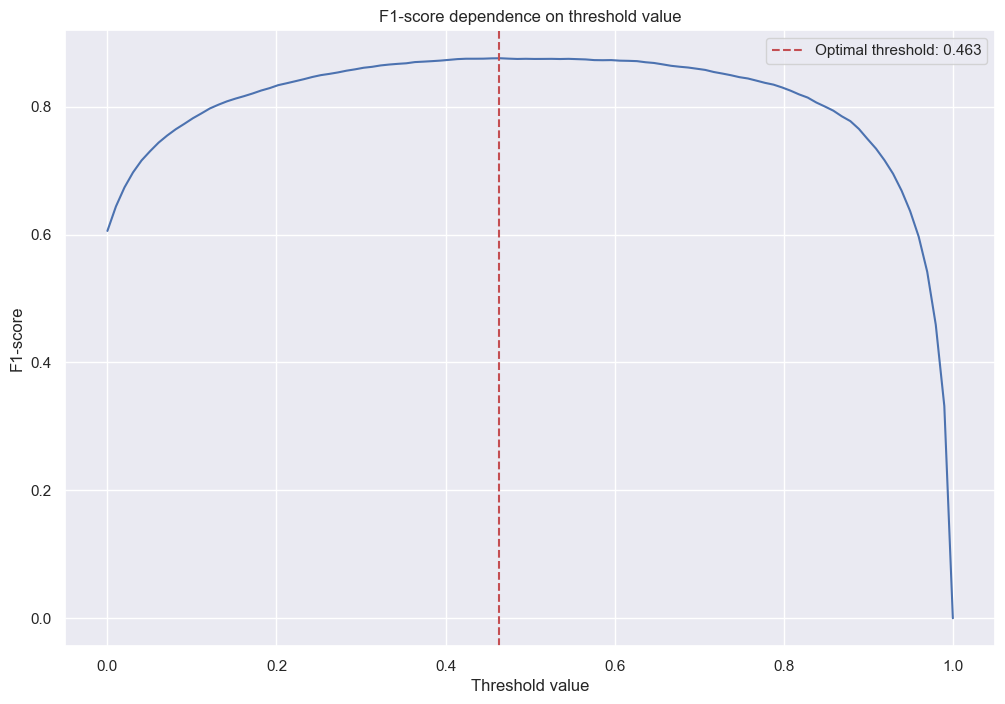

In [24]:
# Visualization of F1-score dependence on threshold
thresholds = np.linspace(0, 1, 100)
f1_scores = []

for threshold in thresholds:
    y_val_pred = val_probabilities > threshold
    f1_scores.append(f1_score(y_val, y_val_pred, zero_division=0))

sns.set(rc={'figure.figsize': (11.7, 8.27)})
plt.figure(figsize=(12, 8))
plt.plot(thresholds, f1_scores)
plt.axvline(x=best_threshold, color='r', linestyle='--',
            label=f'Optimal threshold: {best_threshold}')
plt.xlabel('Threshold value')
plt.ylabel('F1-score')
plt.title('F1-score dependence on threshold value')
plt.legend()
plt.grid(True)
plt.show()

To improve model prediction quality, a new classification threshold was found instead of the standard 0.5 value.

### Model evaluation on test set

In [25]:
# Predictions with optimal threshold
test_probabilities = model.predict_proba(x_test)[:, 1]
test_predictions_optimal = test_probabilities > best_threshold

# Quality metrics on test set
test_accuracy = accuracy_score(y_test, test_predictions_optimal)
test_precision = precision_score(y_test, test_predictions_optimal,
                                 zero_division=0)
test_recall = recall_score(y_test, test_predictions_optimal, zero_division=0)
test_f1 = f1_score(y_test, test_predictions_optimal, zero_division=0)

print('Quality metrics on test set (with optimal threshold):')
print(f'Accuracy: {test_accuracy}')
print(f'Precision: {test_precision}')
print(f'Recall: {test_recall}')
print(f'F1-score: {test_f1}')

Quality metrics on test set (with optimal threshold):
Accuracy: 0.892085001539883
Precision: 0.8835274542429284
Recall: 0.8657404125611399
F1-score: 0.8745435016111708


Similar quality metric values on training, validation, and test sets indicate no overfitting and that the model has reached maximum efficiency on the available data. It's also evident that finding the optimal threshold value didn't improve the model's prediction quality.

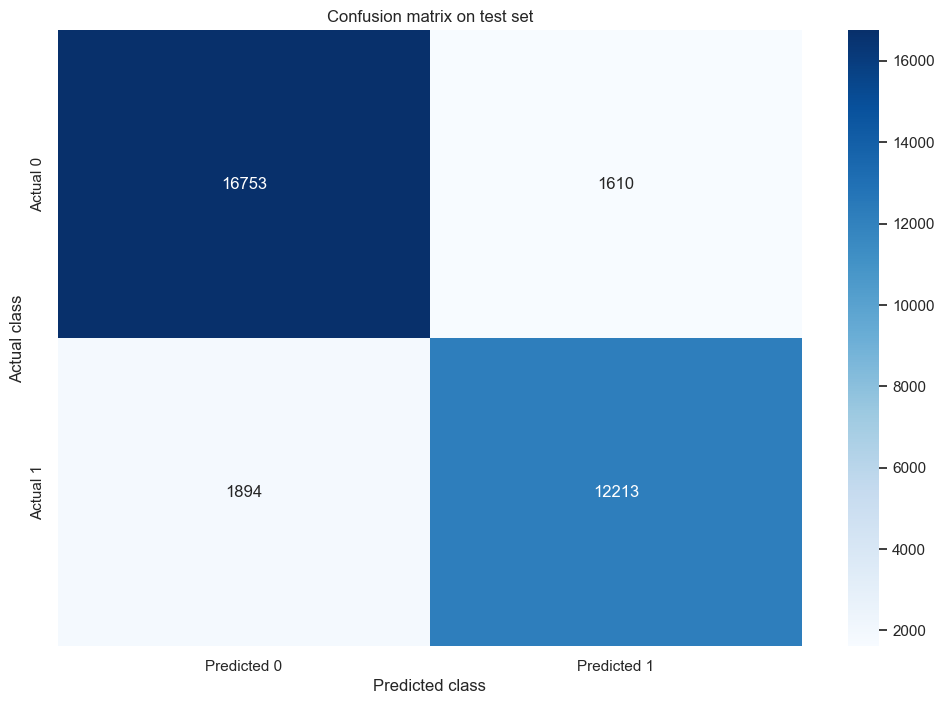

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, test_predictions_optimal)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion matrix on test set')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.show()

In [27]:
# Full classification report
print('Classification report:')
report = classification_report(y_test, test_predictions_optimal,
                               zero_division=0, output_dict=True)
display(pd.DataFrame(report).transpose())

Classification report:


,precision,recall,f1-score,support
False,0.898429,0.912324,0.905323,18363.000000
True,0.883527,0.865740,0.874544,14107.000000
accuracy,0.892085,0.892085,0.892085,0.892085
macro avg,0.890978,0.889032,0.889933,32470.000000
weighted avg,0.891955,0.892085,0.891950,32470.000000


The model demonstrates balanced and high effectiveness in predicting both classes, as evidenced by precision and recall values above 0.86. Overall model accuracy is 89.2%, indicating its reliability for the given task.

### Bootstrap for metric confidence intervals

In [28]:
# Combining test data
x_y_test = x_test.copy(deep=True)
x_y_test['satisfaction'] = y_test.values

boot_accuracies = []
boot_precisions = []
boot_recalls = []
boot_f1_scores = []

n_bootstraps = 1000

print(f'Running bootstrap ({n_bootstraps} iterations)...')
for i in range(n_bootstraps):
    if (i + 1) % 100 == 0:
        print(f'Completed iterations: {i + 1}/{n_bootstraps}')

    # Creating bootstrap sample
    x_y_test_boot = x_y_test.sample(len(x_y_test), replace=True)
    x_test_boot = x_y_test_boot.drop(columns='satisfaction')
    y_test_boot = x_y_test_boot['satisfaction']

    # Model predictions with optimal threshold
    predicted_probas = model.predict_proba(x_test_boot)
    y_pred = predicted_probas[:, 1] >= best_threshold

    # Calculating quality metrics
    boot_accuracies.append(accuracy_score(y_test_boot, y_pred))
    boot_precisions.append(precision_score(y_test_boot, y_pred,
                                           zero_division=0))
    boot_recalls.append(recall_score(y_test_boot, y_pred, zero_division=0))
    boot_f1_scores.append(f1_score(y_test_boot, y_pred, zero_division=0))

def calculate_confidence_interval(metric_values):
    """Calculates confidence intervals (95%)"""
    sorted_metrics = np.sort(metric_values)
    lower_bound = sorted_metrics[int(0.025 * len(sorted_metrics))]
    upper_bound = sorted_metrics[int(0.975 * len(sorted_metrics))]
    return lower_bound, upper_bound

accuracy_ci = calculate_confidence_interval(boot_accuracies)
precision_ci = calculate_confidence_interval(boot_precisions)
recall_ci = calculate_confidence_interval(boot_recalls)
f1_ci = calculate_confidence_interval(boot_f1_scores)

Running bootstrap (1000 iterations)...
Completed iterations: 100/1000
Completed iterations: 200/1000
Completed iterations: 300/1000
Completed iterations: 400/1000
Completed iterations: 500/1000
Completed iterations: 600/1000
Completed iterations: 700/1000
Completed iterations: 800/1000
Completed iterations: 900/1000
Completed iterations: 1000/1000


In [29]:
# Displaying confidence intervals
print('Metric confidence intervals (bootstrap):')
print('Accuracy:')
print(f'Interval mean value: {test_accuracy}')
print(f'Interval: [{accuracy_ci[0]}, {accuracy_ci[1]}]')
print(f'Interval description: (95% CI, width: {
    accuracy_ci[1] - accuracy_ci[0]})')

print('\nPrecision:')
print(f'Interval mean value: {test_precision}')
print(f'Interval: [{precision_ci[0]}, {precision_ci[1]}]')
print(f'Interval description: (95% CI, width: {
    precision_ci[1] - precision_ci[0]})')

print('\nRecall:')
print(f'Interval mean value: {test_recall}')
print(f'Interval: [{recall_ci[0]}, {recall_ci[1]}]')
print(f'Interval description: (95% CI, width: {recall_ci[1] - recall_ci[0]})')

print('\nF1:')
print(f'Interval mean value: {test_f1}')
print(f'Interval: [{f1_ci[0]}, {f1_ci[1]}]')
print(f'Interval description: (95% CI, width: {f1_ci[1] - f1_ci[0]})')

Metric confidence intervals (bootstrap):
Accuracy:
Interval mean value: 0.892085001539883
Interval: [0.8890052356020942, 0.8957499230058515]
Interval description: (95% CI, width: 0.006744687403757332)

Precision:
Interval mean value: 0.8835274542429284
Interval: [0.8779975367673694, 0.888824256525849]
Interval description: (95% CI, width: 0.010826719758479597)

Recall:
Interval mean value: 0.8657404125611399
Interval: [0.8601914214817441, 0.8714023702031602]
Interval description: (95% CI, width: 0.011210948721416147)

F1:
Interval mean value: 0.8745435016111708
Interval: [0.870357646548295, 0.878907781698927]
Interval description: (95% CI, width: 0.008550135150632077)


Bootstrap confidence intervals are very narrow, indicating good model predictive capability. The model performs almost identically in both best and worst cases.

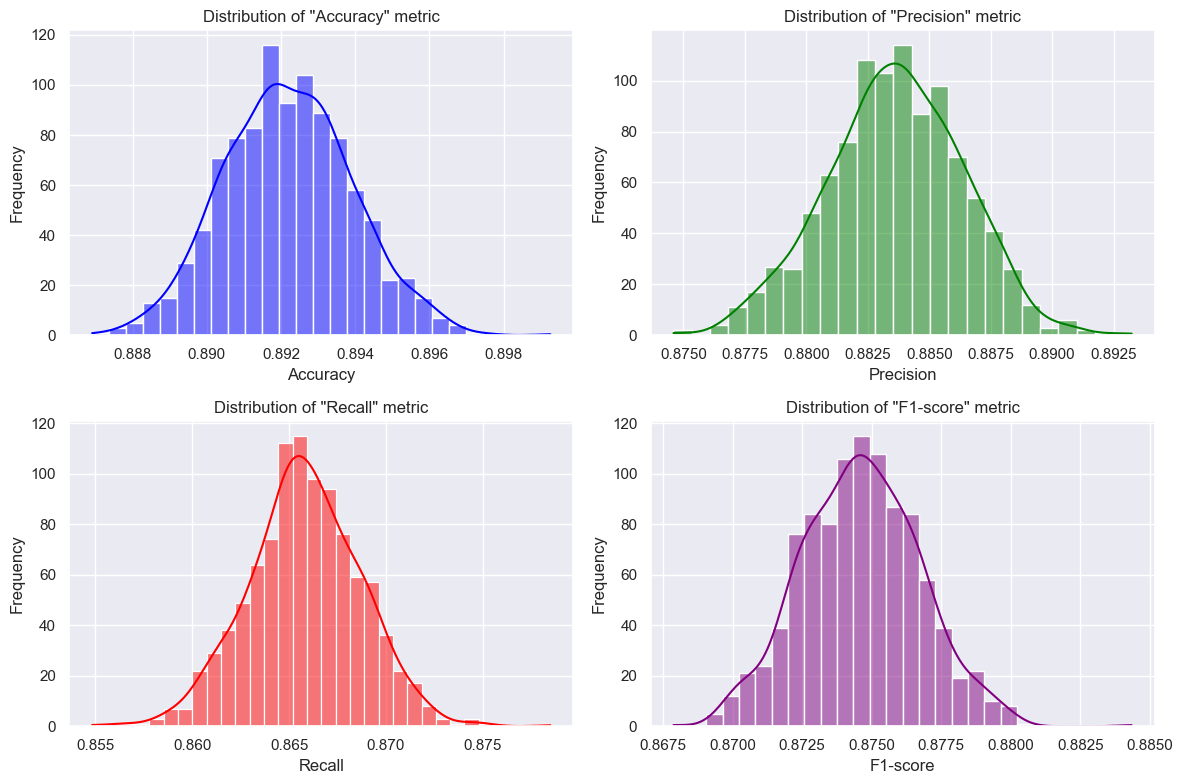

In [30]:
# Visualization of metric distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = [boot_accuracies, boot_precisions, boot_recalls, boot_f1_scores]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors = ['blue', 'green', 'red', 'purple']

for i, (ax, metric, name, color) in enumerate(zip(
        axes.flat, metrics, metric_names, colors)):
    sns.histplot(metric, ax=ax, color=color, kde=True)
    ax.set_title(f'Distribution of "{name}" metric')
    ax.set_xlabel(name)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Model coefficients interpretation

In [31]:
# Getting coefficients and their significance
coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_[0],
    'Exp(Coefficient)': np.exp(model.coef_[0]),
    'Impact on Odds': [
        'Increases' if coef > 0 else 'Decreases' for coef in model.coef_[0]]
})

# Sorting by absolute coefficient value
coefficients_sorted = coefficients.reindex(
    coefficients['Coefficient'].abs().sort_values(ascending=False).index)

print('Model coefficients (sorted by impact):')
display(coefficients_sorted.reset_index(drop=True))

Model coefficients (sorted by impact):


,Feature,Coefficient,Exp(Coefficient),Impact on Odds
0,Inflight wifi service_0,3.080902,21.778031,Increases
1,Inflight wifi service_2,2.853221,17.343554,Increases
2,Online boarding_0,-2.540987,0.078789,Decreases
3,Type of Travel_0,-1.773036,0.169817,Decreases
4,Customer Type_0,-1.313970,0.268751,Decreases
5,Inflight wifi service_1,1.236020,3.441886,Increases
6,Inflight entertainment_2,-1.235898,0.290574,Decreases
7,Type of Travel_1,1.151735,3.163676,Increases
8,Class_0,-0.985789,0.373145,Decreases
9,Online boarding_2,-0.942033,0.389835,Decreases


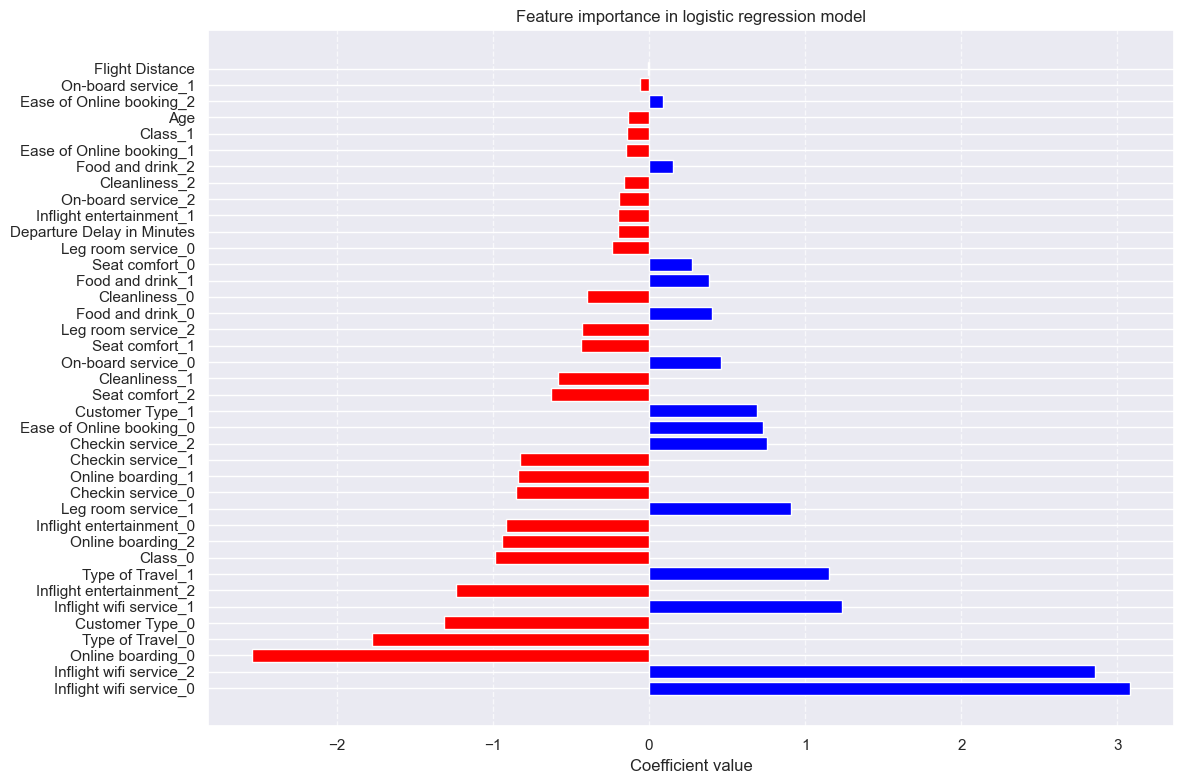

In [32]:
# Visualization of feature importance
plt.figure(figsize=(12, 8))
colors = ['red' if coef < 0 else 'blue'
          for coef in coefficients_sorted['Coefficient']]
plt.barh(coefficients_sorted['Feature'],
         coefficients_sorted['Coefficient'], color=colors)
plt.xlabel('Coefficient value')
plt.title('Feature importance in logistic regression model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Analysis of logistic regression coefficients revealed key influencing factors on flight satisfaction. High ratings for "Inflight wifi service" quality make the most positive contribution, significantly increasing the probability of positive assessment. Conversely, the main negative factors are low ratings for online boarding service ("Online boarding"). The most significant predictors of overall flight quality include online boarding convenience, onboard Wi-Fi quality, and related services. Additionally, the analysis revealed a stable positive correlation between ratings of various services, indicating consistent perception of service quality by passengers.